# Training report cumulative reward

In [13]:
from pathlib import Path
import json

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

REPORT_PATH = Path("cmr_export")
SAVE_PATH = Path("figures")
SAVE_PATH.mkdir(parents=True, exist_ok=True)

METHOD_NAMES = ["Random", "Random Ordered", "GA", "SpaceTimeRL"]
TASK_IDS = ["task1", "task2", "task3", "task4"]
TASK_HOLE_DENSITY = {
    "task1": "10%",
    "task2": "20%",
    "task3": "30%",
    "task4": "40%",
}
TASK_REPORTS = {
    task_id: [
        REPORT_PATH / task_id / "random.json",
        REPORT_PATH / task_id / "random_ordered.json",
        REPORT_PATH / task_id / "ga.json",
        REPORT_PATH / task_id / "spacetime_rl.json",
    ]
    for task_id in TASK_IDS
}
SUCCESS_RATES = {
    "task1": {
        "GA": {0: 0, 1000: 0, 2000: 3 / 5, 3000: 1},
        "Random": {0: 0, 1000: 0, 2000: 1/5, 3000: 1},
        "Random Ordered": {0: 0, 1000: 2/5, 2000: 3/5, 3000: 1},
        "SpaceTimeRL": {0: 0, 700: 1 / 2, 1900: 1, 3000: 1},
    },
    "task2": {
        "GA": {0: 0, 2000: 0, 4000: 1 / 5, 6000: 0, 8000: 0, 10000: 1},
        "Random": {0: 0, 2000: 0, 4000: 0, 6000: 0, 8000: 0, 10000: 3 / 5},
        "Random Ordered": {0: 0, 2000: 0, 4000: 0, 6000: 0, 8000: 1/5, 10000: 3 / 5},
        "SpaceTimeRL": {0: 0, 1100: 1 / 2, 1851: 1, 10000: 1},
    },
    "task3": {
        "Random": {0: 0, 27000: 0, 30000: 4 / 5},
        "Random Ordered": {0: 0, 27000: 0, 30000: 1},
        "GA": {0: 0, 27000: 0, 30000: 1},
        "SpaceTimeRL": {0: 0, 1900: 1 / 2, 3900: 1, 30000: 1},
    },
    "task4": {
        "Random": {0: 0, 56000: 0, 60000: 1},
        "Random Ordered": {0: 0, 56000: 0, 60000: 3 / 5},
        "GA": {0: 0, 56000: 0, 60000: 3 / 5},
        "SpaceTimeRL": {0: 0, 2400: 1 / 2, 15900: 1, 60000: 1},
    },
}

RQ2_SUCCESS_RATES = {
    "task1": {
        "SpaceTimeRL": {
            "20%": 2/2,
            "40%": 2/2,
            "60%": 2/2,
            "80%": 2/2,
        },
        "GA": {
            "20%": 5/5,
            "40%": 2/5,
            "60%": 2/5,
            "80%": 0/5,
        },
        "Random Ordered": {
            "20%": 5/5,
            "40%": 3/5,
            "60%": 3/5,
            "80%": 3/5,
        },
        "Random": {
            "20%": 4/5,
            "40%": 2/5,
            "60%": 2/5,
            "80%": 2/5,
        },
    },
    "task2": {
        "SpaceTimeRL": {
            "20%": 1/2,
            "40%": 1/2,
            "60%": 2/2,
            "80%": 0/2,
        },
        "GA": {
            "20%": 5/5,
            "40%": 4/5,
            "60%": 5/5,
            "80%": 5/5,
        },
        "Random Ordered": {
            "20%": 3/5,
            "40%": 3/5,
            "60%": 3/5,
            "80%": 2/5,
        },
        "Random": {
            "20%": 3/5,
            "40%": 2/5,
            "60%": 2/5,
            "80%": 2/5,
        },
    },
    "task3": {
        "SpaceTimeRL": {
            "20%": 0/2,
            "40%": 0/2,
            "60%": 0/2,
            "80%": 0/2,
        },
        "GA": {
            "20%": 4/5,
            "40%": 4/5,
            "60%": 4/5,
            "80%": 2/5,
        },
        "Random Ordered": {
            "20%": 4/5,
            "40%": 1/5,
            "60%": 1/5,
            "80%": 1/5,
        },
        "Random": {
            "20%": 4/5,
            "40%": 4/5,
            "60%": 4/5,
            "80%": 2/5,
        },
    },
    "task4": {
        "SpaceTimeRL": {
            "20%": 0/2,
            "40%": 0/2,
            "60%": 0/2,
            "80%": 0/2,
        },
        "GA": {
            "20%": 0/5,
            "40%": 0/5,
            "60%": 0/5,
            "80%": 0/5,
        },
        "Random Ordered": {
            "20%": 0/5,
            "40%": 0/5,
            "60%": 0/5,
            "80%": 0/5,
        },
        "Random": {
            "20%": 0/5,
            "40%": 0/5,
            "60%": 0/5,
            "80%": 0/5,
        },
    },
}

def task_title(task_id: str) -> str:
    return f"{task_id.replace('task', 'Task ')} ({TASK_HOLE_DENSITY[task_id]} hole density)"


def reports_from_file(path: Path) -> list[dict]:
    with path.open("r", encoding="utf-8") as file:
        payload = json.load(file)
    reports = payload.get("reports")
    if isinstance(reports, list):
        return [item for item in reports if isinstance(item, dict)]
    return [payload]


def generate_df_rows(paths: list[Path], names: list[str]) -> list[dict]:
    rows = []
    for path, name in zip(paths, names):
        for run_index, report in enumerate(reports_from_file(path), start=1):
            label = report.get("target_label") or report.get("target_checkpoint_id") or f"Run {run_index}"
            for episode, cumulative_reward in report.get("cumulative_reward_points", []):
                rows.append({
                    "file": name,
                    "run": label,
                    "episode": int(episode),
                    "cumulative_reward": float(cumulative_reward),
                })
    return rows


In [14]:
sns.set_theme(style="whitegrid")


def save_plot(fig, save_path: Path) -> None:
    save_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(save_path, dpi=300, bbox_inches="tight")


def save_figure_versions(fig, output_base: Path) -> list[Path]:
    output_base.parent.mkdir(parents=True, exist_ok=True)
    output_paths = [output_base.with_suffix(".pdf"), output_base.with_suffix(".png")]
    fig.savefig(output_paths[0], bbox_inches="tight")
    fig.savefig(output_paths[1], dpi=300, bbox_inches="tight")
    return output_paths


def plot_cumulative_reward(
    paths: list[Path],
    names: list[str],
    save_path: Path | None = None,
    ax=None,
    title: str = "Average cumulative reward",
    show_legend: bool = True,
):
    rows = generate_df_rows(paths, names)
    df = pd.DataFrame(rows, columns=["file", "run", "episode", "cumulative_reward"])

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 5))
    else:
        fig = ax.figure

    sns.lineplot(
        data=df,
        x="episode",
        y="cumulative_reward",
        hue="file",
        estimator="mean",
        errorbar="sd",
        linewidth=2.2,
        legend=show_legend,
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("Episode")
    ax.set_ylabel("Cumulative reward")

    legend = ax.get_legend()
    if legend is not None:
        legend.set_title(None)
        if not show_legend:
            legend.remove()

    if save_path:
        fig.tight_layout()
        save_plot(fig, save_path)

    return fig, ax, df


In [15]:
def success_rate_dataframe(success_rates: dict) -> pd.DataFrame:
    df = pd.DataFrame.from_dict(success_rates, orient="index").transpose()
    df = df.sort_index()
    ordered_columns = [name for name in METHOD_NAMES if name in df.columns]
    df = df[ordered_columns]
    df.index.name = "Episode"
    return df


def plot_success_rate(
    success_rates: dict,
    save_path: Path | None = None,
    ax=None,
    title: str = "Success rate",
    show_legend: bool = True,
):
    df = success_rate_dataframe(success_rates)
    df_long = (
        df.reset_index()
        .melt(id_vars="Episode", var_name="method", value_name="success_rate")
    )
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))
    else:
        fig = ax.figure

    sns.lineplot(
        data=df_long,
        x="Episode",
        y="success_rate",
        hue="method",
        style="method",
        markers=True,
        dashes=False,
        linewidth=2.2,
        alpha=0.65,
        markeredgecolor="black",
        markeredgewidth=1.0,
        markersize=8,
        legend=show_legend,
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("Episode")
    ax.set_ylabel("Success rate")
    ax.set_ylim(-0.02, 1.02)

    legend = ax.get_legend()
    if legend is not None:
        legend.set_title(None)
        if not show_legend:
            legend.remove()

    if save_path:
        fig.tight_layout()
        save_plot(fig, save_path)

    return fig, ax, df


## RQ2 success rate by map dissimilarity

,task_id,task,hole_density,method,dissimilarity_label,dissimilarity,success_rate
8,task1,Task 1 (10% hole density),10%,GA,20%,0.2,1.0
9,task1,Task 1 (10% hole density),10%,GA,40%,0.4,0.4
10,task1,Task 1 (10% hole density),10%,GA,60%,0.6,0.4
11,task1,Task 1 (10% hole density),10%,GA,80%,0.8,0.0
0,task1,Task 1 (10% hole density),10%,Random,20%,0.2,0.8
...,...,...,...,...,...,...,...
55,task4,Task 4 (40% hole density),40%,Random Ordered,80%,0.8,0.0
60,task4,Task 4 (40% hole density),40%,SpaceTimeRL,20%,0.2,0.0
61,task4,Task 4 (40% hole density),40%,SpaceTimeRL,40%,0.4,0.0
62,task4,Task 4 (40% hole density),40%,SpaceTimeRL,60%,0.6,0.0


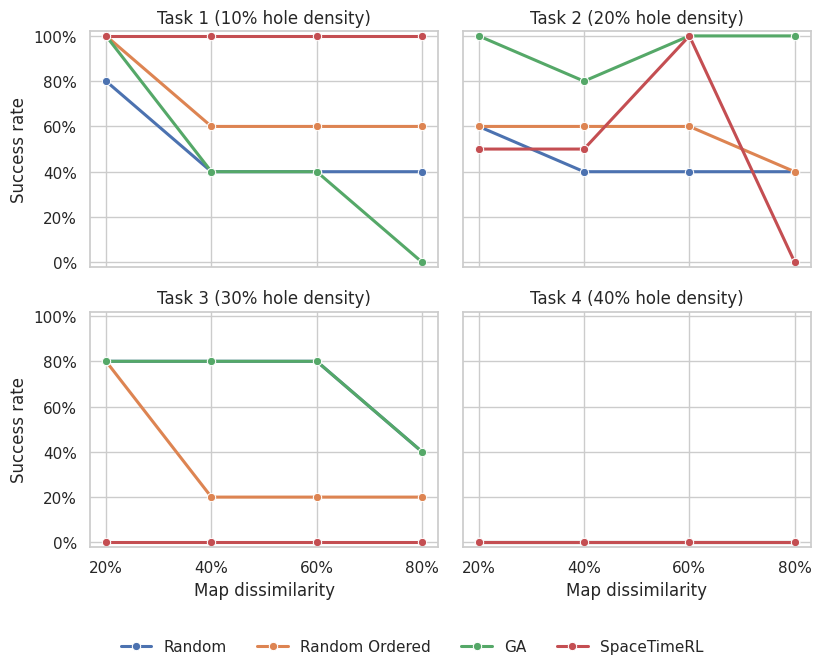

In [16]:
from matplotlib.ticker import PercentFormatter


def rq2_add_shared_legend(fig, source_ax, *, bottom: float, ncol: int = 4) -> None:
    handles, labels = source_ax.get_legend_handles_labels()
    for ax in fig.axes:
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()
    fig.legend(
        handles,
        labels,
        loc="lower center",
        bbox_to_anchor=(0.5, bottom),
        ncol=ncol,
        frameon=False,
    )


def percent_label_to_float(label: str) -> float:
    return float(str(label).rstrip("%")) / 100


def rq2_success_rate_dataframe(success_rates: dict = RQ2_SUCCESS_RATES) -> pd.DataFrame:
    rows = []
    ordered_task_ids = [task_id for task_id in TASK_IDS if task_id in success_rates]
    ordered_task_ids.extend(task_id for task_id in success_rates if task_id not in ordered_task_ids)

    for task_id in ordered_task_ids:
        for method_name in METHOD_NAMES:
            method_rates = success_rates[task_id].get(method_name, {})
            for dissimilarity_label, success_rate in method_rates.items():
                rows.append({
                    "task_id": task_id,
                    "task": task_title(task_id),
                    "hole_density": TASK_HOLE_DENSITY.get(task_id, ""),
                    "method": method_name,
                    "dissimilarity_label": dissimilarity_label,
                    "dissimilarity": percent_label_to_float(dissimilarity_label),
                    "success_rate": float(success_rate),
                })

    return pd.DataFrame(rows).sort_values(["task_id", "method", "dissimilarity"])


def plot_rq2_success_rates(
    success_rates: dict = RQ2_SUCCESS_RATES,
    save_base: Path | None = SAVE_PATH / "rq2_success_rate_by_dissimilarity",
):
    df = rq2_success_rate_dataframe(success_rates)
    task_ids = list(df["task_id"].drop_duplicates())
    if not task_ids:
        raise ValueError("RQ2_SUCCESS_RATES is empty.")

    ncols = min(2, len(task_ids))
    nrows = (len(task_ids) + ncols - 1) // ncols
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(4.2 * ncols, 3.4 * nrows),
        sharex=True,
        sharey=True,
        squeeze=False,
    )

    first_ax = axes.flat[0]
    x_ticks = sorted(df["dissimilarity"].unique())
    palette = dict(zip(METHOD_NAMES, sns.color_palette(n_colors=len(METHOD_NAMES))))

    for ax, task_id in zip(axes.flat, task_ids):
        task_df = df[df["task_id"] == task_id]
        sns.lineplot(
            data=task_df,
            x="dissimilarity",
            y="success_rate",
            hue="method",
            hue_order=METHOD_NAMES,
            palette=palette,
            marker="o",
            dashes=False,
            linewidth=2.2,
            legend=(ax is first_ax),
            ax=ax,
        )
        ax.set_title(task_title(task_id))
        ax.set_xlabel("Map dissimilarity")
        ax.set_ylabel("Success rate")
        ax.set_xticks(x_ticks)
        ax.set_xticklabels([f"{x:.0%}" for x in x_ticks])
        ax.set_ylim(-0.02, 1.02)
        ax.yaxis.set_major_formatter(PercentFormatter(1.0))

    for ax in axes.flat[len(task_ids):]:
        ax.set_axis_off()

    rq2_add_shared_legend(fig, first_ax, bottom=0.005, ncol=len(METHOD_NAMES))
    fig.tight_layout(rect=(0, 0.08, 1, 1))

    if save_base:
        save_figure_versions(fig, save_base)

    return fig, axes, df


rq2_success_rate_fig, _, rq2_success_rate_df = plot_rq2_success_rates()
display(rq2_success_rate_df)


## RQ2 success rate summary table

In [17]:
TABLE_PATH = Path("eval") / "tables"
TABLE_PATH.mkdir(parents=True, exist_ok=True)


def rq2_success_rate_summary(success_rates: dict = RQ2_SUCCESS_RATES) -> pd.DataFrame:
    df = rq2_success_rate_dataframe(success_rates)
    if df.empty:
        return pd.DataFrame(columns=["Task", "Hole density", "Map dissimilarity", *METHOD_NAMES])

    summary = (
        df.pivot_table(
            index=["task_id", "hole_density", "dissimilarity", "dissimilarity_label"],
            columns="method",
            values="success_rate",
            aggfunc="first",
        )
        .reset_index()
        .sort_values(["task_id", "dissimilarity"])
    )
    summary.columns.name = None
    summary["Task"] = summary["task_id"].str.replace("task", "Task ", regex=False)

    for method_name in METHOD_NAMES:
        if method_name not in summary.columns:
            summary[method_name] = pd.NA

    summary = summary.rename(
        columns={
            "hole_density": "Hole density",
            "dissimilarity_label": "Map dissimilarity",
        }
    )
    return summary[["Task", "Hole density", "Map dissimilarity", *METHOD_NAMES]]


def format_latex_percent(value: float | int) -> str:
    if pd.isna(value):
        return "--"
    return f"{round(float(value) * 100):.0f}\\%"


def rq2_success_rate_summary_to_latex(df: pd.DataFrame) -> str:
    lines = [
        r"\begin{table}[htbp]",
        r"    \centering",
        r"    \small",
        r"    \caption{Success rate on RQ2 mutated maps by hole density and map dissimilarity.}",
        r"    \label{tab:rq2-success-rate-summary}",
        r"    \begin{tabular}{llrrrrr}",
        r"        \toprule",
        r"        Task & Hole density & Map dissimilarity & Random & Random Ordered & GA & SpaceTimeRL \\",
        r"        \midrule",
    ]

    grouped = list(df.groupby(["Task", "Hole density"], sort=False))
    for group_index, ((task, hole_density), group) in enumerate(grouped):
        row_count = len(group)
        for row_index, (_, row) in enumerate(group.iterrows()):
            if row_index == 0:
                task_cell = rf"\multirow{{{row_count}}}{{*}}{{{task}}}"
                density_cell = rf"\multirow{{{row_count}}}{{*}}{{{str(hole_density).replace('%', r'\%')}}}"
            else:
                task_cell = ""
                density_cell = ""

            values = [
                task_cell,
                density_cell,
                str(row["Map dissimilarity"]).replace("%", r"\%"),
                *(format_latex_percent(row[method_name]) for method_name in METHOD_NAMES),
            ]
            lines.append("        " + " & ".join(values) + r" \\")

        if group_index != len(grouped) - 1:
            lines.append(r"        \midrule")

    lines.extend([
        r"        \bottomrule",
        r"    \end{tabular}",
        r"\end{table}",
    ])
    return "\n".join(lines)


rq2_success_rate_summary_df = rq2_success_rate_summary()
rq2_success_rate_summary_latex = rq2_success_rate_summary_to_latex(rq2_success_rate_summary_df)
rq2_success_rate_summary_latex_path = TABLE_PATH / "rq2_success_rate_summary.tex"
rq2_success_rate_summary_latex_path.write_text(rq2_success_rate_summary_latex + "\n", encoding="utf-8")

display(rq2_success_rate_summary_df)
print(rq2_success_rate_summary_latex)
print(f"\nSaved to {rq2_success_rate_summary_latex_path}")


,Task,Hole density,Map dissimilarity,Random,Random Ordered,GA,SpaceTimeRL
0,Task 1,10%,20%,0.8,1.0,1.0,1.0
1,Task 1,10%,40%,0.4,0.6,0.4,1.0
2,Task 1,10%,60%,0.4,0.6,0.4,1.0
3,Task 1,10%,80%,0.4,0.6,0.0,1.0
4,Task 2,20%,20%,0.6,0.6,1.0,0.5
5,Task 2,20%,40%,0.4,0.6,0.8,0.5
6,Task 2,20%,60%,0.4,0.6,1.0,1.0
7,Task 2,20%,80%,0.4,0.4,1.0,0.0
8,Task 3,30%,20%,0.8,0.8,0.8,0.0
9,Task 3,30%,40%,0.8,0.2,0.8,0.0


\begin{table}[htbp]
    \centering
    \small
    \caption{Success rate on RQ2 mutated maps by hole density and map dissimilarity.}
    \label{tab:rq2-success-rate-summary}
    \begin{tabular}{llrrrrr}
        \toprule
        Task & Hole density & Map dissimilarity & Random & Random Ordered & GA & SpaceTimeRL \\
        \midrule
        \multirow{4}{*}{Task 1} & \multirow{4}{*}{10\%} & 20\% & 80\% & 100\% & 100\% & 100\% \\
         &  & 40\% & 40\% & 60\% & 40\% & 100\% \\
         &  & 60\% & 40\% & 60\% & 40\% & 100\% \\
         &  & 80\% & 40\% & 60\% & 0\% & 100\% \\
        \midrule
        \multirow{4}{*}{Task 2} & \multirow{4}{*}{20\%} & 20\% & 60\% & 60\% & 100\% & 50\% \\
         &  & 40\% & 40\% & 60\% & 80\% & 50\% \\
         &  & 60\% & 40\% & 60\% & 100\% & 100\% \\
         &  & 80\% & 40\% & 40\% & 100\% & 0\% \\
        \midrule
        \multirow{4}{*}{Task 3} & \multirow{4}{*}{30\%} & 20\% & 80\% & 80\% & 80\% & 0\% \\
         &  & 40\% & 80\% & 20\% & 80\% & 0\%

## Task 1

(<Figure size 1000x500 with 1 Axes>,
 <Axes: title={'center': 'Average cumulative reward'}, xlabel='Episode', ylabel='Cumulative reward'>,
               file                                                run  \
 0           Random  Checkpoint 033 | Frozen Lake 12x12 - RQ1 Task ...   
 1           Random  Checkpoint 033 | Frozen Lake 12x12 - RQ1 Task ...   
 2           Random  Checkpoint 033 | Frozen Lake 12x12 - RQ1 Task ...   
 3           Random  Checkpoint 033 | Frozen Lake 12x12 - RQ1 Task ...   
 4           Random  Checkpoint 033 | Frozen Lake 12x12 - RQ1 Task ...   
 ...            ...                                                ...   
 50995  SpaceTimeRL  Checkpoint 053 | Frozen Lake 12x12 - RQ1 Task ...   
 50996  SpaceTimeRL  Checkpoint 053 | Frozen Lake 12x12 - RQ1 Task ...   
 50997  SpaceTimeRL  Checkpoint 053 | Frozen Lake 12x12 - RQ1 Task ...   
 50998  SpaceTimeRL  Checkpoint 053 | Frozen Lake 12x12 - RQ1 Task ...   
 50999  SpaceTimeRL  Checkpoint 053 | Frozen La

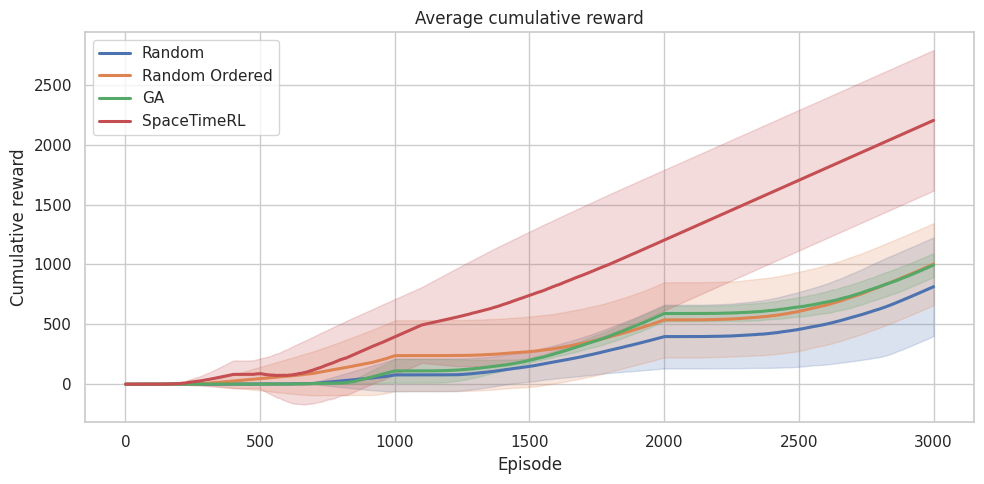

In [18]:
plot_cumulative_reward(
    [
        REPORT_PATH / "task1"/ "random.json",
        REPORT_PATH / "task1"/ "random_ordered.json",
        REPORT_PATH / "task1"/ "ga.json",
        REPORT_PATH / "task1"/ "spacetime_rl.json",
    ], ["Random", "Random Ordered", "GA", "SpaceTimeRL"],
    save_path=SAVE_PATH / "task1_cumulative_reward.png")

(<Figure size 600x600 with 1 Axes>,
 <Axes: title={'center': 'Success rate'}, xlabel='Episode', ylabel='Success rate'>,
          Random  Random Ordered   GA  SpaceTimeRL
 Episode                                          
 0           0.0             0.0  0.0          0.0
 700         NaN             NaN  NaN          0.5
 1000        0.0             0.0  0.0          NaN
 1900        NaN             NaN  NaN          1.0
 2000        0.0             0.0  0.6          NaN
 3000        0.8             0.6  1.0          1.0)

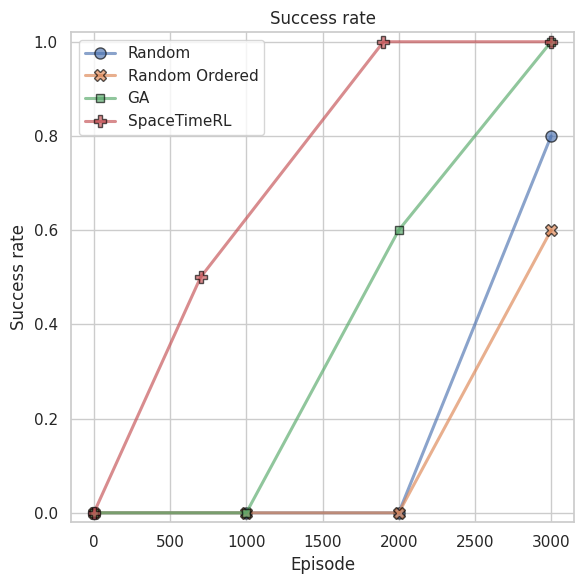

In [19]:
plot_success_rate({
    "GA":{
        0:0,
        1000:0,
        2000:3/5,
        3000:1
    },
    "Random":{
        0:0,
        1000:0,
        2000:0,
        3000:4/5
    },
    "Random Ordered":{
        0:0,
        1000:0,
        2000:0,
        3000:3/5
    },
    "SpaceTimeRL":{
        0:0,
        700:1/2,
        1900:1,
        3000:1,
    }
}, save_path=SAVE_PATH / "task1_success_rate.png")

## Task 2

(<Figure size 1000x500 with 1 Axes>,
 <Axes: title={'center': 'Average cumulative reward'}, xlabel='Episode', ylabel='Cumulative reward'>,
                file                                                run  \
 0            Random  Checkpoint 055 | Frozen Lake 12x12 - RQ1 Task ...   
 1            Random  Checkpoint 055 | Frozen Lake 12x12 - RQ1 Task ...   
 2            Random  Checkpoint 055 | Frozen Lake 12x12 - RQ1 Task ...   
 3            Random  Checkpoint 055 | Frozen Lake 12x12 - RQ1 Task ...   
 4            Random  Checkpoint 055 | Frozen Lake 12x12 - RQ1 Task ...   
 ...             ...                                                ...   
 169995  SpaceTimeRL  Checkpoint 087 | Frozen Lake 12x12 - RQ1 Task ...   
 169996  SpaceTimeRL  Checkpoint 087 | Frozen Lake 12x12 - RQ1 Task ...   
 169997  SpaceTimeRL  Checkpoint 087 | Frozen Lake 12x12 - RQ1 Task ...   
 169998  SpaceTimeRL  Checkpoint 087 | Frozen Lake 12x12 - RQ1 Task ...   
 169999  SpaceTimeRL  Checkpoint 087

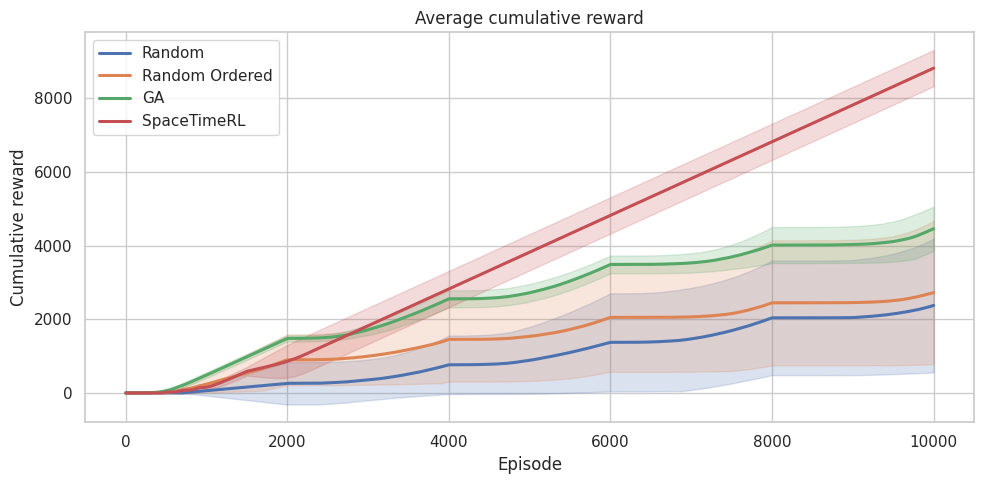

In [20]:
plot_cumulative_reward(
    [
        REPORT_PATH / "task2"/ "random.json",
        REPORT_PATH / "task2"/ "random_ordered.json",
        REPORT_PATH / "task2"/ "ga.json", # to fix: performance seems to be worse than random
        REPORT_PATH / "task2"/ "spacetime_rl.json",
    ], [
        "Random", 
        "Random Ordered", 
        "GA",
        "SpaceTimeRL"], 
    save_path=SAVE_PATH / "task2_cumulative_reward.png")

(<Figure size 600x600 with 1 Axes>,
 <Axes: title={'center': 'Success rate'}, xlabel='Episode', ylabel='Success rate'>,
          Random  Random Ordered   GA  SpaceTimeRL
 Episode                                          
 0           0.0             0.0  0.0          0.0
 1100        NaN             NaN  NaN          0.5
 1851        NaN             NaN  NaN          1.0
 2000        0.0             NaN  0.0          NaN
 4000        0.2             NaN  0.2          NaN
 6000        0.0             NaN  0.0          NaN
 8000        0.0             0.0  0.2          NaN
 10000       0.8             0.8  1.0          1.0)

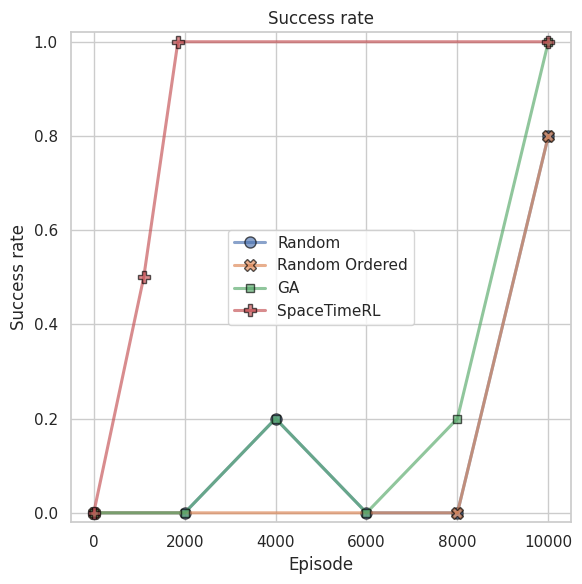

In [21]:
plot_success_rate({
    "GA":{
        0:0,
        2000:0,
        4000:1/5,
        6000:0,
        8000:1/5,
        10000:1
    },
    "Random":{
        0:0,
        2000:0,
        4000:1/5,
        6000:0,
        8000:0,
        10000:4/5
    },
    "Random Ordered":{
        0:0,
        8000:0,
        10000:4/5
    },
    "SpaceTimeRL":{
        0:0,
        1100:1/2,
        1851:1,
        10000:1,
    }
}, save_path=SAVE_PATH / "task2_success_rate.png")

## Task 3

(<Figure size 1000x500 with 1 Axes>,
 <Axes: title={'center': 'Average cumulative reward'}, xlabel='Episode', ylabel='Cumulative reward'>,
                file                                                run  \
 0            Random  Checkpoint 110 | Frozen Lake 12x12 - RQ1 Task ...   
 1            Random  Checkpoint 110 | Frozen Lake 12x12 - RQ1 Task ...   
 2            Random  Checkpoint 110 | Frozen Lake 12x12 - RQ1 Task ...   
 3            Random  Checkpoint 110 | Frozen Lake 12x12 - RQ1 Task ...   
 4            Random  Checkpoint 110 | Frozen Lake 12x12 - RQ1 Task ...   
 ...             ...                                                ...   
 509995  SpaceTimeRL  Checkpoint 165 | Frozen Lake 12x12 - RQ1 Task ...   
 509996  SpaceTimeRL  Checkpoint 165 | Frozen Lake 12x12 - RQ1 Task ...   
 509997  SpaceTimeRL  Checkpoint 165 | Frozen Lake 12x12 - RQ1 Task ...   
 509998  SpaceTimeRL  Checkpoint 165 | Frozen Lake 12x12 - RQ1 Task ...   
 509999  SpaceTimeRL  Checkpoint 165

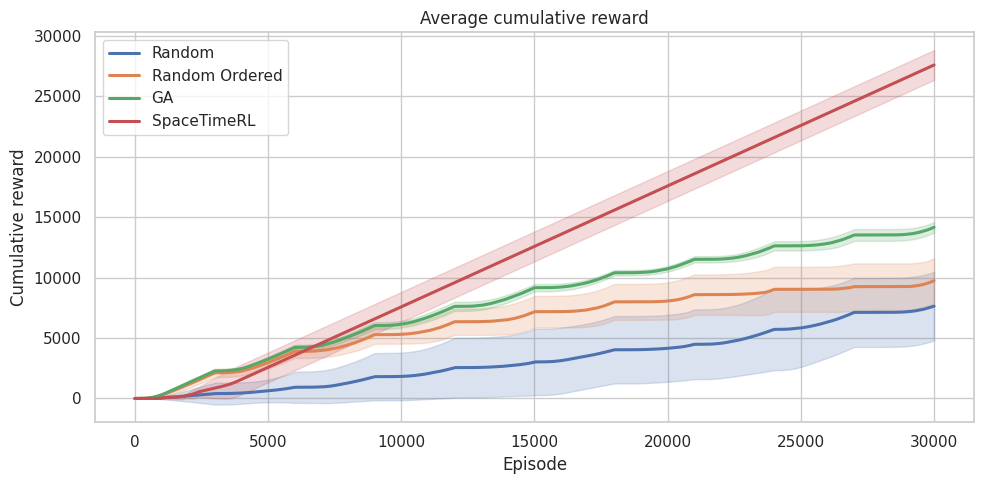

In [22]:
plot_cumulative_reward(
    [
        REPORT_PATH / "task3"/ "random.json",
        REPORT_PATH / "task3"/ "random_ordered.json",
        REPORT_PATH / "task3"/ "ga.json",
        REPORT_PATH / "task3"/ "spacetime_rl.json",
    ], ["Random", "Random Ordered", "GA", 
        "SpaceTimeRL"
    ], save_path=SAVE_PATH / "task3_cumulative_reward.png")

(<Figure size 600x600 with 1 Axes>,
 <Axes: title={'center': 'Success rate'}, xlabel='Episode', ylabel='Success rate'>,
          Random  Random Ordered   GA  SpaceTimeRL
 Episode                                          
 0           0.0             0.0  0.0          0.0
 1900        NaN             NaN  NaN          0.5
 3900        NaN             NaN  NaN          1.0
 21000       NaN             0.0  NaN          NaN
 24000       NaN             0.2  NaN          NaN
 27000       0.0             0.0  0.0          NaN
 30000       0.8             0.6  1.0          1.0)

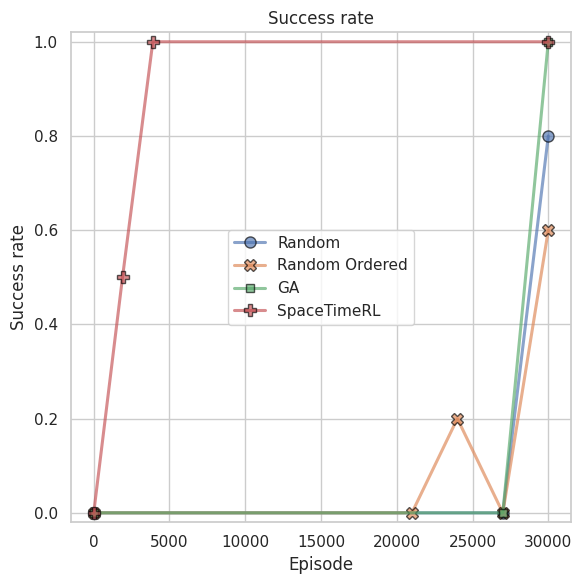

In [23]:
plot_success_rate({
    "Random":{
        0:0,
        27000:0,
        30000:4/5
    },
    "Random Ordered":{
        0:0,
        21000:0,
        24000:1/5,
        27000:0,
        30000:3/5
    },
    "GA":{
        0:0,
        27000:0,
        30000:1
    },
    "SpaceTimeRL":{
        0:0,
        1900:1/2,
        3900:1,
        30000:1
    }
}, save_path=SAVE_PATH / "task3_success_rate.png")

## Task 4

(<Figure size 1000x500 with 1 Axes>,
 <Axes: title={'center': 'Average cumulative reward'}, xlabel='Episode', ylabel='Cumulative reward'>,
                 file                                                run  \
 0             Random  Checkpoint 015 | Frozen Lake 12x12 - RQ1 Task ...   
 1             Random  Checkpoint 015 | Frozen Lake 12x12 - RQ1 Task ...   
 2             Random  Checkpoint 015 | Frozen Lake 12x12 - RQ1 Task ...   
 3             Random  Checkpoint 015 | Frozen Lake 12x12 - RQ1 Task ...   
 4             Random  Checkpoint 015 | Frozen Lake 12x12 - RQ1 Task ...   
 ...              ...                                                ...   
 1019995  SpaceTimeRL  Checkpoint 092 | Frozen Lake 12x12 - RQ1 Task ...   
 1019996  SpaceTimeRL  Checkpoint 092 | Frozen Lake 12x12 - RQ1 Task ...   
 1019997  SpaceTimeRL  Checkpoint 092 | Frozen Lake 12x12 - RQ1 Task ...   
 1019998  SpaceTimeRL  Checkpoint 092 | Frozen Lake 12x12 - RQ1 Task ...   
 1019999  SpaceTimeRL  Ch

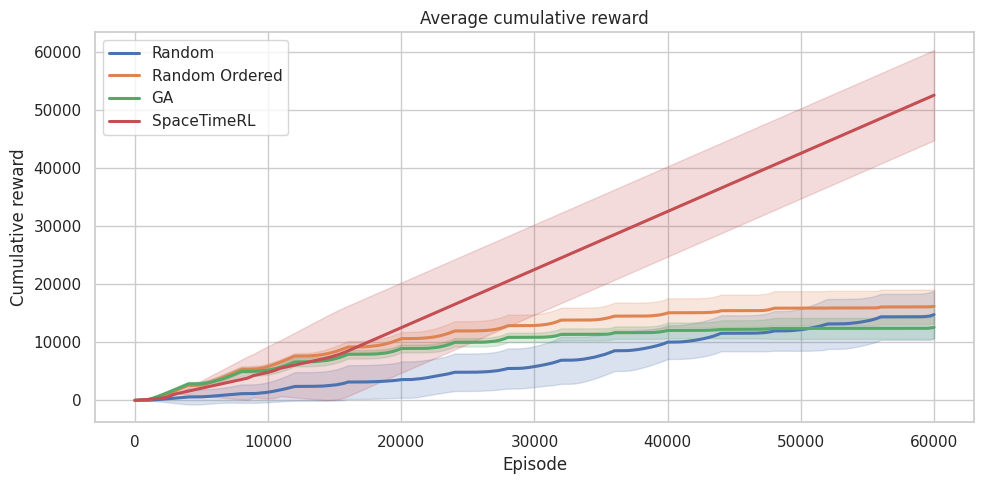

In [24]:
plot_cumulative_reward(
    [
        REPORT_PATH / "task4"/ "random.json",
        REPORT_PATH / "task4"/ "random_ordered.json",
        REPORT_PATH / "task4"/ "ga.json",
        REPORT_PATH / "task4"/ "spacetime_rl.json",
    ], ["Random", "Random Ordered", "GA", "SpaceTimeRL"],
    save_path=SAVE_PATH / "task4_cumulative_reward.png")

(<Figure size 600x600 with 1 Axes>,
 <Axes: title={'center': 'Success rate'}, xlabel='Episode', ylabel='Success rate'>,
          Random  Random Ordered   GA  SpaceTimeRL
 Episode                                          
 0           0.0             0.0  0.0          0.0
 2400        NaN             NaN  NaN          0.5
 15900       NaN             NaN  NaN          1.0
 56000       0.0             0.0  0.0          NaN
 60000       0.8             0.4  0.6          1.0)

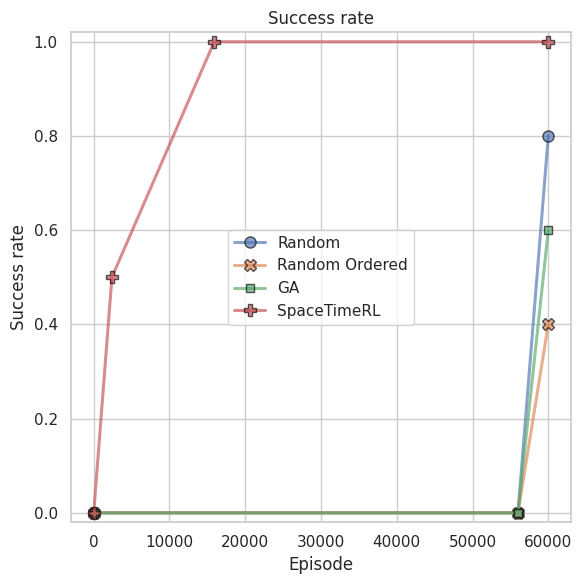

In [25]:
plot_success_rate({
    "Random":{
        0:0,
        56000:0,
        60000:4/5
    },
    "Random Ordered":{
        0:0,
        56000:0,
        60000:2/5
    },
    "GA":{
        0:0,
        56000:0,
        60000:3/5
    },
    "SpaceTimeRL":{
        0:0,
        2400:1/2,
        15900:1,
        60000:1
    }
}, save_path=SAVE_PATH / "task4_success_rate.png")

## Combined report figures

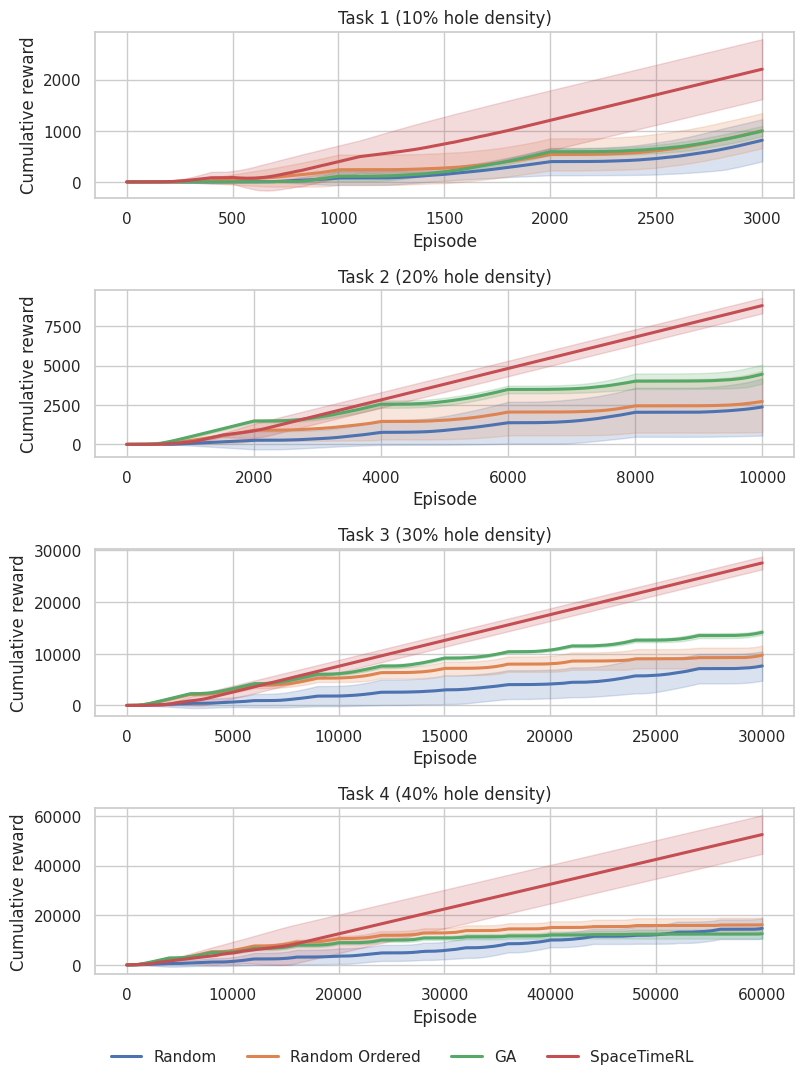

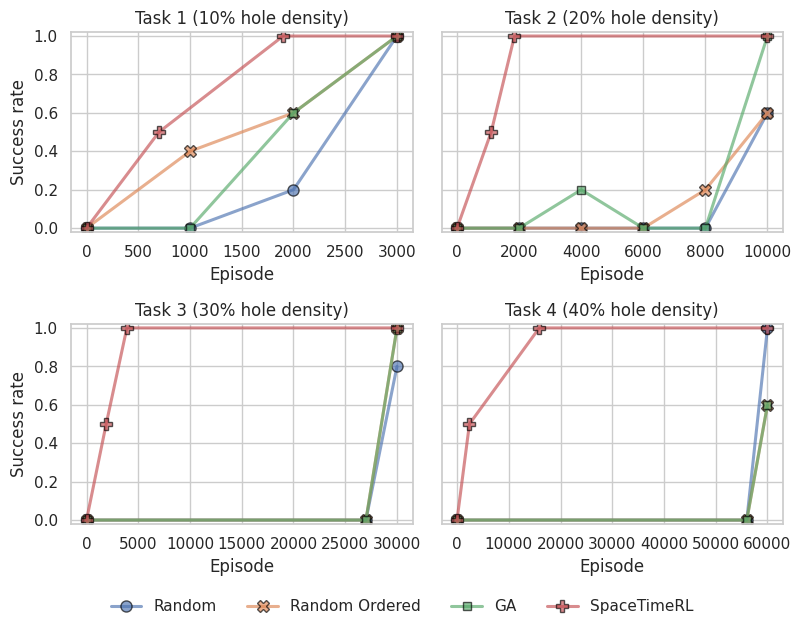

In [26]:
def add_shared_legend(fig, source_ax, *, bottom: float, ncol: int = 4) -> None:
    handles, labels = source_ax.get_legend_handles_labels()
    for ax in fig.axes:
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()
    fig.legend(
        handles,
        labels,
        loc="lower center",
        bbox_to_anchor=(0.5, bottom),
        ncol=ncol,
        frameon=False,
    )


def plot_all_cumulative_rewards(
    task_ids: list[str] = TASK_IDS,
    save_base: Path | None = None,
):
    fig, axes = plt.subplots(len(task_ids), 1, figsize=(8.2, 11.2), sharex=False)
    first_ax = axes[0]

    for ax, task_id in zip(axes, task_ids):
        plot_cumulative_reward(
            TASK_REPORTS[task_id],
            METHOD_NAMES,
            ax=ax,
            title=task_title(task_id),
            show_legend=(ax is first_ax),
        )

    #fig.suptitle("Average cumulative reward by hole density", fontsize=14)
    add_shared_legend(fig, first_ax, bottom=0.005, ncol=len(METHOD_NAMES))
    fig.tight_layout(rect=(0, 0.035, 1, 0.975))

    if save_base:
        save_figure_versions(fig, save_base)

    return fig, axes


def plot_all_success_rates(
    task_ids: list[str] = TASK_IDS,
    save_base: Path | None = None,
):
    fig, axes = plt.subplots(2, 2, figsize=(8.2, 6.8), sharex=False, sharey=True)
    flat_axes = axes.ravel()
    first_ax = flat_axes[0]

    for ax, task_id in zip(flat_axes, task_ids):
        plot_success_rate(
            SUCCESS_RATES[task_id],
            ax=ax,
            title=task_title(task_id),
            show_legend=(ax is first_ax),
        )

    #fig.suptitle("Success rate by hole density", fontsize=14)
    add_shared_legend(fig, first_ax, bottom=0.005, ncol=len(METHOD_NAMES))
    fig.tight_layout(rect=(0, 0.055, 1, 0.94))

    if save_base:
        save_figure_versions(fig, save_base)

    return fig, axes


combined_cumulative_reward_fig, _ = plot_all_cumulative_rewards(
    save_base=SAVE_PATH / "all_cumulative_reward_by_hole_density"
)
combined_success_rate_fig, _ = plot_all_success_rates(
    save_base=SAVE_PATH / "all_success_rate_by_hole_density"
)


## Cumulative reward summary table

In [27]:
TABLE_PATH = Path("tables")
TABLE_PATH.mkdir(parents=True, exist_ok=True)


def final_cumulative_reward_summary(task_ids: list[str] = TASK_IDS) -> pd.DataFrame:
    rows = []
    for task_id in task_ids:
        final_episodes = []
        row = {
            "Hole density": TASK_HOLE_DENSITY[task_id],
        }

        for report_path, method_name in zip(TASK_REPORTS[task_id], METHOD_NAMES):
            final_rewards = []
            for report in reports_from_file(report_path):
                points = report.get("cumulative_reward_points", [])
                if not points:
                    continue
                episode, cumulative_reward = points[-1]
                final_episodes.append(int(episode))
                final_rewards.append(float(cumulative_reward))

            row[method_name] = pd.Series(final_rewards).mean()

        row["Episodes"] = max(final_episodes)
        rows.append(row)

    return pd.DataFrame(rows, columns=["Hole density", "Episodes", *METHOD_NAMES])


def format_latex_int(value: float | int) -> str:
    return f"{round(value):,}"


def format_latex_approx(value: float | int) -> str:
    if pd.isna(value):
        return "--"
    return rf"{format_latex_int(value)}"


def cumulative_reward_summary_to_latex(df: pd.DataFrame) -> str:
    lines = [
        r"\begin{table}[htbp]",
        r"    \centering",
        r"    \caption{Average final cumulative reward by hole density.}",
        r"    \label{tab:cumulative-reward-summary}",
        r"    \begin{tabular}{rrrrrr}",
        r"        \toprule",
        r"        Hole density & Episodes & Random & Random Ordered & GA & SpaceTimeRL \\",
        r"        \midrule",
    ]

    for _, row in df.iterrows():
        density = str(row["Hole density"]).replace("%", r"\%")
        values = [
            density,
            format_latex_int(row["Episodes"]),
            *(format_latex_approx(row[method_name]) for method_name in METHOD_NAMES),
        ]
        lines.append("        " + " & ".join(values) + r" \\")

    lines.extend([
        r"        \bottomrule",
        r"    \end{tabular}",
        r"\end{table}",
    ])
    return "\n".join(lines)


cumulative_reward_summary = final_cumulative_reward_summary()
cumulative_reward_summary_latex = cumulative_reward_summary_to_latex(cumulative_reward_summary)
cumulative_reward_summary_latex_path = TABLE_PATH / "cumulative_reward_summary.tex"
cumulative_reward_summary_latex_path.write_text(cumulative_reward_summary_latex + "\n", encoding="utf-8")

display(cumulative_reward_summary)
print(cumulative_reward_summary_latex)
print(f"\nSaved to {cumulative_reward_summary_latex_path}")


,Hole density,Episodes,Random,Random Ordered,GA,SpaceTimeRL
0,10%,3000,814.2,1002.2,995.0,2203.0
1,20%,10000,2377.8,2725.4,4461.2,8823.0
2,30%,30000,7638.0,9742.2,14155.4,27574.0
3,40%,60000,14759.2,16174.8,12559.0,52507.5


\begin{table}[htbp]
    \centering
    \caption{Average final cumulative reward by hole density.}
    \label{tab:cumulative-reward-summary}
    \begin{tabular}{rrrrrr}
        \toprule
        Hole density & Episodes & Random & Random Ordered & GA & SpaceTimeRL \\
        \midrule
        10\% & 3,000 & 814 & 1,002 & 995 & 2,203 \\
        20\% & 10,000 & 2,378 & 2,725 & 4,461 & 8,823 \\
        30\% & 30,000 & 7,638 & 9,742 & 14,155 & 27,574 \\
        40\% & 60,000 & 14,759 & 16,175 & 12,559 & 52,508 \\
        \bottomrule
    \end{tabular}
\end{table}

Saved to tables/cumulative_reward_summary.tex
